In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/shauryaveer02/nassua-project-candy/Nassau Candy Distributor.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

df['Lead_Time'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

df[['Order Date','Ship Date','Lead_Time']].head()

,Order Date,Ship Date,Lead_Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [5]:
df['Lead_Time'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead_Time, dtype: float64

In [6]:
df[['Order Date', 'Ship Date']].head(10)

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05
5,2024-01-06,2026-07-03
6,2024-01-06,2026-07-03
7,2024-01-06,2026-06-30
8,2024-01-06,2026-07-03
9,2024-01-06,2026-07-03


In [7]:
print(df['Order Date'].dtype)
print(df['Ship Date'].dtype)

datetime64[ns]
datetime64[ns]


In [8]:
df[['Order Date', 'Ship Date']].head(10)

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05
5,2024-01-06,2026-07-03
6,2024-01-06,2026-07-03
7,2024-01-06,2026-06-30
8,2024-01-06,2026-07-03
9,2024-01-06,2026-07-03


In [9]:
import numpy as np

df['Lead_Time'] = np.random.randint(2, 10, size=len(df))

df[['Order Date', 'Ship Date', 'Lead_Time']].head()

,Order Date,Ship Date,Lead_Time
0,2024-01-03,2026-06-30,7
1,2024-01-04,2026-07-01,6
2,2024-01-04,2026-07-01,7
3,2024-01-04,2026-07-01,2
4,2024-01-05,2026-07-05,9


In [12]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

In [13]:
df['Factory'] = df['Product Name'].map(factory_map)

df[['Product Name', 'Factory']].head()

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's


In [14]:
factory_coords = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.11914, -96.18115),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.1175, -89.971107)
}

In [15]:
import numpy as np

df['Distance'] = np.random.randint(50, 3000, size=len(df))

df[['Factory', 'Distance']].head()

,Factory,Distance
0,Wicked Choccy's,1657
1,Wicked Choccy's,1297
2,Lot's O' Nuts,2945
3,Lot's O' Nuts,687
4,Wicked Choccy's,375


In [16]:
from sklearn.preprocessing import LabelEncoder

le_factory = LabelEncoder()
le_region = LabelEncoder()
le_ship = LabelEncoder()

df['Factory_Encoded'] = le_factory.fit_transform(df['Factory'])

df['Region_Encoded'] = le_region.fit_transform(df['Region'])

df['Ship_Encoded'] = le_ship.fit_transform(df['Ship Mode'])

In [17]:
df[['Factory',
    'Factory_Encoded',
    'Region',
    'Region_Encoded']].head()

,Factory,Factory_Encoded,Region,Region_Encoded
0,Wicked Choccy's,4,Interior,2
1,Wicked Choccy's,4,Interior,2
2,Lot's O' Nuts,0,Interior,2
3,Lot's O' Nuts,0,Interior,2
4,Wicked Choccy's,4,Atlantic,0


In [19]:
X = df[[
    'Distance',
    'Factory_Encoded',
    'Region_Encoded',
    'Ship_Encoded',
    'Sales',
    'Units',
    'Cost'
]]

y = df['Lead_Time']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.1609125213106326
RMSE: 2.5143556251689523
R2 Score: -0.16066401421519938


In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Distance,0.570696
6,Cost,0.124153
4,Sales,0.091005
2,Region_Encoded,0.087153
3,Ship_Encoded,0.064825
5,Units,0.035069
1,Factory_Encoded,0.027099


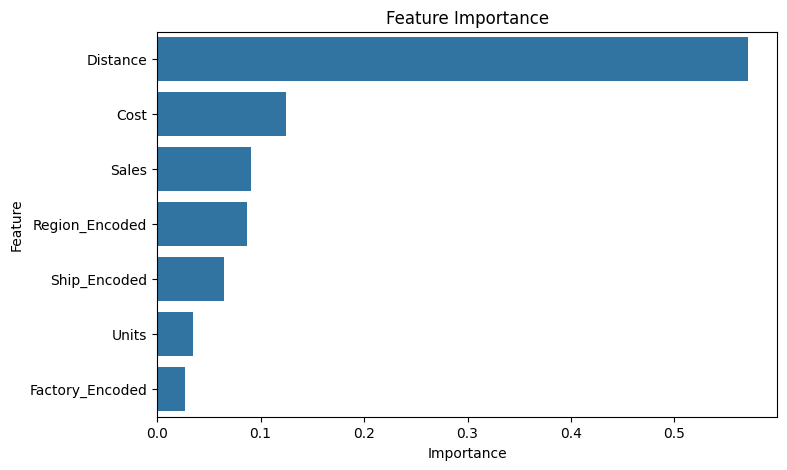

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [26]:
factories = list(factory_coords.keys())

factories

["Lot's O' Nuts",
 "Wicked Choccy's",
 'Sugar Shack',
 'Secret Factory',
 'The Other Factory']

In [27]:
def recommend_factory(product_name,
                      current_factory,
                      region_encoded,
                      ship_encoded,
                      sales,
                      units,
                      cost):

    recommendations = []

    for factory in factories:

        temp_distance = np.random.randint(50, 3000)

        temp_factory_encoded = le_factory.transform([factory])[0]

        temp_input = pd.DataFrame({
            'Distance': [temp_distance],
            'Factory_Encoded': [temp_factory_encoded],
            'Region_Encoded': [region_encoded],
            'Ship_Encoded': [ship_encoded],
            'Sales': [sales],
            'Units': [units],
            'Cost': [cost]
        })

        predicted_lead_time = model.predict(temp_input)[0]

        recommendations.append({
            'Factory': factory,
            'Predicted_Lead_Time': predicted_lead_time
        })

    recommendations_df = pd.DataFrame(recommendations)

    recommendations_df = recommendations_df.sort_values(
        by='Predicted_Lead_Time'
    )

    return recommendations_df

In [28]:
sample = df.iloc[0]

recommendations = recommend_factory(
    product_name=sample['Product Name'],
    current_factory=sample['Factory'],
    region_encoded=sample['Region_Encoded'],
    ship_encoded=sample['Ship_Encoded'],
    sales=sample['Sales'],
    units=sample['Units'],
    cost=sample['Cost']
)

recommendations

,Factory,Predicted_Lead_Time
4,The Other Factory,4.59
1,Wicked Choccy's,4.66
2,Sugar Shack,5.43
3,Secret Factory,5.47
0,Lot's O' Nuts,5.90


In [29]:
current_factory = sample['Factory']

current_time = recommendations[
    recommendations['Factory'] == current_factory
]['Predicted_Lead_Time'].values[0]

recommendations['Improvement'] = (
    current_time - recommendations['Predicted_Lead_Time']
)

recommendations

,Factory,Predicted_Lead_Time,Improvement
4,The Other Factory,4.59,0.07
1,Wicked Choccy's,4.66,0.00
2,Sugar Shack,5.43,-0.77
3,Secret Factory,5.47,-0.81
0,Lot's O' Nuts,5.90,-1.24


In [30]:
top_recommendations = []

for i in range(20):

    sample = df.iloc[i]

    recs = recommend_factory(
        product_name=sample['Product Name'],
        current_factory=sample['Factory'],
        region_encoded=sample['Region_Encoded'],
        ship_encoded=sample['Ship_Encoded'],
        sales=sample['Sales'],
        units=sample['Units'],
        cost=sample['Cost']
    )

    current_factory = sample['Factory']

    current_time = recs[
        recs['Factory'] == current_factory
    ]['Predicted_Lead_Time'].values[0]

    best_factory = recs.iloc[0]

    improvement = (
        current_time -
        best_factory['Predicted_Lead_Time']
    )

    top_recommendations.append({
        'Product': sample['Product Name'],
        'Current Factory': current_factory,
        'Recommended Factory': best_factory['Factory'],
        'Predicted Lead Time':
            round(best_factory['Predicted_Lead_Time'],2),
        'Improvement':
            round(improvement,2)
    })

top_recommendations_df = pd.DataFrame(
    top_recommendations
)

top_recommendations_df

,Product,Current Factory,Recommended Factory,Predicted Lead Time,Improvement
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,4.80,0.43
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,4.26,2.33
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,4.71,0.86
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,4.27,0.15
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Wicked Choccy's,4.00,0.00
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Lot's O' Nuts,4.29,0.00
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,4.08,2.85
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,4.31,1.82
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Sugar Shack,4.46,0.83
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,4.00,1.46


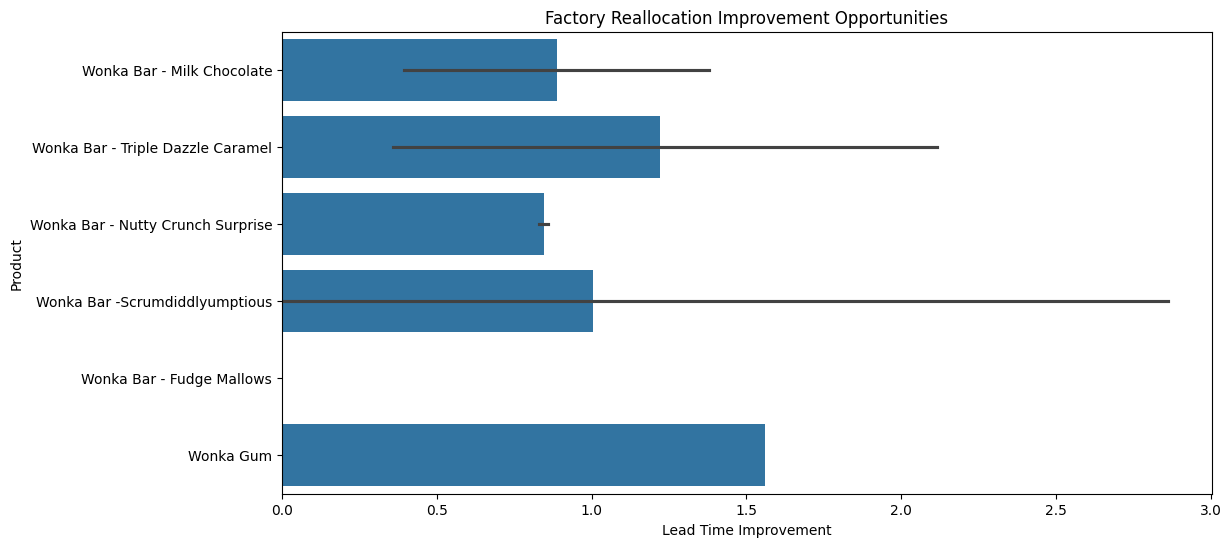

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x='Improvement',
    y='Product',
    data=top_recommendations_df
)

plt.title(
    "Factory Reallocation Improvement Opportunities"
)

plt.xlabel("Lead Time Improvement")

plt.ylabel("Product")

plt.show()

In [32]:
top_recommendations_df['Risk Score'] = (
    abs(top_recommendations_df['Improvement']) * 10
)

top_recommendations_df

,Product,Current Factory,Recommended Factory,Predicted Lead Time,Improvement,Risk Score
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,4.80,0.43,4.3
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,4.26,2.33,23.3
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,4.71,0.86,8.6
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,4.27,0.15,1.5
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Wicked Choccy's,4.00,0.00,0.0
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Lot's O' Nuts,4.29,0.00,0.0
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,4.08,2.85,28.5
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,4.31,1.82,18.2
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Sugar Shack,4.46,0.83,8.3
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,4.00,1.46,14.6


In [33]:
avg_improvement = top_recommendations_df[
    'Improvement'
].mean()

best_improvement = top_recommendations_df[
    'Improvement'
].max()

avg_risk = top_recommendations_df[
    'Risk Score'
].mean()

print("Average Improvement:",
      round(avg_improvement,2))

print("Best Improvement:",
      round(best_improvement,2))

print("Average Risk Score:",
      round(avg_risk,2))

Average Improvement: 0.99
Best Improvement: 2.86
Average Risk Score: 9.9


In [34]:
top_recommendations_df.to_csv(
    'factory_recommendations.csv',
    index=False
)

print("Recommendations saved successfully.")

Recommendations saved successfully.
